In [2]:
!pip install -q langchain-openai langchain-community streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.0 which is incompatible.


In [3]:
# 기본 제공 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import os
import openai
import ast
import re

from typing import TypedDict, Annotated, List, Optional, Literal, Dict, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI

# 더 필요한 라이브러리가 있다면 추가합시다. -----




/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

load_api_keys('api_key.txt')

In [5]:
print(os.environ['OPENAI_API_KEY'][:30])

sk-proj-1m6t4SG9VslVwGgEBMQuXd


In [ ]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "proj2_agent"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

In [6]:
ReasonCode = Literal["OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"]

class ReviewState(TypedDict):
    messages: Annotated[list, add_messages]
    input_review: str
    max_num: int
    current_num: int
    score: int
    next_step: Optional[Literal["analyzer", "critic", "end"]]
    result: dict
    aspect_list: List[str]
    criti_score: str

    # 추가
    current_agent: Optional[str]

    reason_code: Optional[ReasonCode]
    repair_directive: str



In [7]:
visor_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
analyzer_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
criti_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)

In [8]:
# 정책 및 필요 함수 준비 : 아래 내용을 수정해서 사용하세요.

REASON_CODES = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"}
RETRYABLE = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR"}

REPAIR_TEMPLATES = {
    "OUTPUT_ERROR": "dict 1개만 출력. 코드블록/설명 없이 items 구조와 label(0/1)을 맞춰라.",
    "SCOPE_ERROR": "aspect는 보습, 가격, 향, 포장만 사용하라. 다른 표현은 가장 가까운 값으로 매핑하라.",
    "EVIDENCE_ERROR": "리뷰 원문에 실제 언급되지 않은 aspect는 제외하라.",
    "QUALITY_ERROR": "리뷰에 없는 내용을 만들지 말고, 애매하면 해당 aspect는 제외하라."
}

# 딕셔너리 파싱 함
def parse_dict(text, default):
    try:
        return ast.literal_eval(text)
    except:
        return default

In [19]:
def analyzer_node(state: ReviewState):
    review = state.get("input_review") or "" # 리뷰 원문
    aspect = state.get("aspect_list") or []   # 후보 속성 리스트
    score = state.get("score") or 0   # 리뷰 별점
    directive = state.get("repair_directive") or ""
    retry_cnt = state.get("current_num") or 0
    feedback  = directive if directive else "없음 (최초 분석)"


    sys = """
    너는 리뷰 분석 전문가야. 다음 지침에 따라 입력받은 사용자의 리뷰를 분석해줘.
    만약 [수정 요청 피드백]이 제공된다면, 이전의 실수를 교정하여 결과를 다시 작성해야 해.


    [지침]
    1. 제시된 [후보 속성] 중에서 리뷰에 언급된 것만 추출해.
    2. aspect 리스트에 담긴 속성의 순서는 반드시 [후보 속성]에 나열된 순서를 유지해야 해.
    3. 각 속성에 대한 만족도를 판별해. 만족/긍정은 1, 불만족/부정은 0이야.
    4. label 리스트의 값은 aspect 리스트의 순서와 1:1로 정확히 매칭되어야 해.
    5. 리뷰에 명시된 별점 score를 추출해.
    6. 결과는 반드시 아래 JSON 형식으로만 출력하고, 다른 설명은 하지마.


    [출력 형식]
    {
      "review": "리뷰 원문",
      "aspect": ["추출된 속성 리스트"],
      "label": [각 속성에 대응하는 1 또는 0 리스트],
      "score": 별점숫자
    }
    """


    human = f"""
    [리뷰 원문]
    {review}


    [후보 속성]
    {aspect}


    [별점 숫자]
    {score}


    [수정 요청 피드백]  ← {retry_cnt}회차 재시도
    {feedback}
    """


    resp = analyzer_llm.invoke([
        SystemMessage(content=sys),
        HumanMessage(content=human)
    ])


    content = resp.content.strip()
    content = content.replace("```json", "").replace("```", "").strip()


    data_dict = json.loads(content)


    return {
        # 실행 로그 누적
        "messages": [AIMessage(content=f"[Analyzer Result]\n{resp.content}")],
        "next_step": "supervisor",
        "result": data_dict,        # Analyzer가 만든 분석 결과 JSON을 넣음
        "current_agent": "analyzer", # 현재 실행 중인 Agent (Trace 가독성용)
        "reason_code": None,
        "criti_score": ""
    }

In [10]:
def critic_node(state: ReviewState):
    input_review = state.get("input_review", "")
    result = state.get("result", {})
    aspect_list = state.get("aspect_list", [])
    reason_code = state.get("reason_code", None)


    sys_msg = """
    # 역할: 너는 리뷰 분석 결과 정확성을 면밀히 검토하는 검증 Agent.
    - analyzer 가 추출한 결과가 리뷰 원문과 논리적으로 일치하는지 검토해줘.

    # 지침
    1. 일관성: 추출된 'aspect'가 실제 리뷰 원문에 언급된 내용인지 확인. (언급되지 않은 속성은 포함 X)
            - 직접 언급되지 않았더라도 문맥 상 의미가 통하면 허용. (예: '효과 좋다' -> '보습' 허용)
            - 리뷰에 전혀 관련 없는 속성이 포함되어 있다면 오류.
    2. 정확성: 각 'aspect'에 매칭된 'label' (1: 만족, 0: 불만족)이 리뷰의 맥락과 맞는지 확인.
    3. 형식: 결과가 JSON 형식을 유지하고 있는지 확인.
    4. 순서: 추출된 'aspect' 들은 [후보 속성]에 나열된 상대적 순서를 반드시 유지해야함.
            - 일부 속성이 빠지더라도 남은 속성들 사이의 순서는 유지되어야함.
            - 예: 후보가 [A, B, C, D]이고 추출이 [A, C]라면 순서가 맞는 것으로 판단.


    # 출력 형식
    검토 후 반드시 아래 형식으로만 출력. 다른 설명은 하지마.
    [FEEDBACK]
    - (문제가 있으면 구체적으로, 없으면 '문제 없음'으로 작성)
    [VERDICT]
    reason_code: 아래 중 하나만 출력 (예: reason_code: NONE)
    - OK: 분석 결과에 문제 없음.
    - OUTPUT_ERROR: 출력 형식 또는 JSON 구조 오류.
    - SCOPE_ERROR: 관련 없는 속성이 포함됨.
    - EVIDENCE_ERROR: 후보 속성에는 있지만 리뷰 원문에 언급이 없는 속성이 포함됨.
    - QUALITY_ERROR: 긍정/부정 판단 오류.
    """

    human_msg = f"""
    [리뷰 원문]
    {input_review}


    [후보 속성]
    {aspect_list}


    [Analyzer 분석 결과]
    {result}


    [reason_code]
    {reason_code}
    """

    response = criti_llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    reason_code = None
    for line in response.content.split("\n"):
      if "reason_code:" in line:
        value = line.split("reason_code:")[-1].strip()
        reason_code = None if value == "OK" else value



    return{
        "messages":[AIMessage(content=f"[CRITIC RESULT] \n {response.content}")],
        "criti_score":response.content,
        "next_step": "supervisor",
        "reason_code": reason_code,
        "current_agent":"critic"
    }

In [16]:
def supervisor_node(state: ReviewState):
    reason = state.get("criti_score")
    current_cnt = state.get("current_num", 0)
    max_cnt = state.get("max_num", 3)
    result = state.get("result")

    if not result:
        return {
            "next_step": "analyzer",
            "current_agent": "supervisor"
        }

    if reason is None and state.get("current_agent") == "analyzer":
        return {
            "next_step": "critic",
            "current_agent": "supervisor",
            "current_num": current_cnt + 1
        }

    if reason is None or reason == "OK":
        return {
            "next_step": "end",
            "current_agent": "supervisor"
        }

    if reason in RETRYABLE and current_cnt < max_cnt:
        directive = REPAIR_TEMPLATES.get(reason, "가이드에 맞춰 다시 분석하세요.")
        return {
            "next_step": "analyzer",
            "current_agent": "supervisor",
            "repair_directive": directive,
            "current_num": current_cnt + 1
        }

    print(f"분석 중단 (사유: {reason} / 시도: {current_cnt})")
    return {
        "next_step": "end",
        "current_agent": "supervisor",
    }

In [17]:
def route_next(state: ReviewState):
    return state["next_step"]

In [20]:
builder = StateGraph(ReviewState)

builder.add_node("analyzer", analyzer_node)
builder.add_node("critic", critic_node)
builder.add_node("supervisor",supervisor_node)

builder.add_edge(START, "supervisor")

builder.add_conditional_edges("supervisor", route_next,
    { "analyzer": "analyzer",
        "critic": "critic", "end": END }
)

builder.add_edge("analyzer", "supervisor")
builder.add_edge("critic", "supervisor")

app = builder.compile()

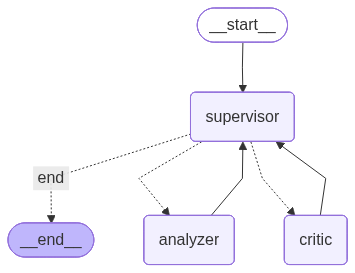

In [21]:
app

* 실행 테스트

In [22]:
review = '''
보습력은 소문대로 정말 쫀쫀하고 좋은데, 향이 너무 강해서 머리가 아파요. 아, 포장은 꼼꼼하게 잘 왔어요!
'''
# 테스트 입력 데이터
test_input = {
    "input_review": review,
    "aspect_list": ["보습", "가격", "향", "포장"],
    "score": 4,
    "max_num": 3,
    "current_num": 0,
    "result": "",
    "criti_score": ""
}

In [23]:
result = app.invoke(test_input)

분석 중단 (사유:  / 시도: 0)


In [ ]:
print(result["result"])

{'review': '보습력은 소문대로 정말 쫀쫀하고 좋은데, 향이 너무 강해서 머리가 아파요. 아, 포장은 꼼꼼하게 잘 왔어요!', 'aspect': ['보습', '향', '포장'], 'label': [1, 0, 1], 'score': 4}


In [ ]:
df = pd.read_csv("data.csv")
reviews = df["review"].tolist()

In [ ]:
def clear_all_data():
    conn = sqlite3.connect("user_review_db.db")
    cursor = conn.cursor()

    cursor.execute("DELETE FROM user_reviews")

    conn.commit()
    conn.close()

def init_db():
  conn = sqlite3.connect("user_review_db.db")
  cursor = conn.cursor()

  cursor.execute("""
CREATE TABLE IF NOT EXISTS user_reviews (
    id INTEGER PRIMARY KEY,
    review TEXT,
    aspect TEXT,
    label TEXT,
    score INTEGER,
    updated_at DATETIME DEFAULT CURRENT_TIMESTAMP
)
""")

  conn.commit()
  conn.close()

def insert_review_data_db(review_list):
  conn = sqlite3.connect("user_review_db.db")
  cursor = conn.cursor()

  for review in review_list:
    cursor.execute(
        "INSERT INTO user_reviews (review) VALUES (?)", (review, )
    )
  conn.commit()
  conn.close()


In [ ]:
# 함수 생성
# 1) 미처리 리뷰 조회 함수
def select_None_analyze():
  conn = sqlite3.connect("user_review_db.db")
  cursor = conn.cursor()
  cursor.execute("SELECT review FROM user_reviews WHERE aspect IS NULL")
  rows = cursor.fetchall()
  conn.close()

  clean_reviews = [row[0] for row in rows]
  return clean_reviews


# 2) Agent 결과에서 aspect, label 추출 함수
def extract_review_elements(clean_reviews):
  result = []
  for review in clean_reviews:
    print("-리뷰 분석 시작합니다.-")
    initial_state = {
                "input_review": review,
                "score": 1,
                "aspect_list": ["보습", "가격", "향", "포장"],
                "max_num": 3,
                "current_num": 0,
                "messages": []
    }

    final_state = app.invoke(initial_state)
    print("-분석 완료-")
    result.append({
        "aspect": final_state["result"]["aspect"],
        "label": final_state["result"]["label"],
        "score": final_state["result"]["score"]})
  return result


# 3) DB 업데이트
def update_db(clean_reviews, result):
  conn = sqlite3.connect("user_review_db.db")
  cursor = conn.cursor()


  for i in range (len(result)):
    aspect = result[i]["aspect"]
    label = result[i]["label"]
    score = result[i]["score"]
    review_text = clean_reviews[i].strip()

    cursor.execute(
        "UPDATE user_reviews SET aspect = ?, label = ?, score = ? WHERE review = ?",
        (
              json.dumps(aspect, ensure_ascii=False),
              json.dumps(label),
              score,
              review_text
          )
    )

  conn.commit()
  conn.close()

# 4) batch 실행
def start_batch():
  init_db()
  clear_all_data()
  insert_review_data_db(reviews)
  None_analyze_reviews = select_None_analyze()
  if len(None_analyze_reviews) == 0:
    print("-분석할 리뷰가 없습니다.-")
  else:
    print(f"-분석할 리뷰{len(None_analyze_reviews)}개 감지됐습니다-\n-분석을 시작합니다.-")
    analyzed_results = extract_review_elements(None_analyze_reviews)
    print("-분석이 완료됐습니다.-\n-Update를 실행합니다-")
    update_db(None_analyze_reviews, analyzed_results)
    print("-Update가 완료됐습니다.-")




In [ ]:
# 배치 실행
start_batch()

# 실행 결과 확인
conn = sqlite3.connect("user_review_db.db")
cursor = conn.cursor()
cursor.execute("SELECT * FROM user_reviews")
rows = cursor.fetchall()
for row in rows:
    print(row)
conn.close()

In [ ]:
!apt-get -y install fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (18.7 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118251 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
%%writefile app.py
import streamlit as st
import sqlite3
import json
import ast
import os
from typing import TypedDict, Optional, Dict, Any, Literal

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import openai
import re

from typing import TypedDict, Annotated, List, Optional, Literal, Dict, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI

# ==================================================
# 0. 기본 설정
# ==================================================
DB_PATH = "user_review_db.db"
ASPECT_LIST = ["보습", "가격", "향", "포장"]

st.set_page_config(page_title="상품 리뷰 분석 Agent", layout="wide")

# 한글 폰트 설정 (Colab에서 fonts-nanum 설치 시 자동 적용)
def set_korean_font():
    candidates = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
    ]
    for path in candidates:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            font_name = fm.FontProperties(fname=path).get_name()
            plt.rcParams["font.family"] = font_name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()

# ==================================================
# 1. Agent
# ==================================================
# State 준비
class ReviewState(TypedDict):
    messages: Annotated[list, add_messages]
    input_review: str
    max_num: int
    current_num: int
    score: int
    next_step: Optional[Literal["analyzer", "critic", "end"]]
    result: dict
    aspect_list: List[str]
    criti_score: str

# LLM 준비
visor_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
analyzer_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
criti_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)

# 노드1 : analyzer_node
def analyzer_node(state: ReviewState):
    review = state.get("input_review") or ""
    result = state.get("result") or {}
    aspect_list = state.get("aspect_list") or []
    score = state.get("score") or 0
    feedback = state.get("criti_score") or "없음 (최초 분석)"

    sys = """
너는 화장품 리뷰 분석 전문가야.
다음 지침에 따라 입력받은 사용자의 리뷰를 분석해줘.
만약 [수정 요청 피드백]이 제공된다면, 이전의 실수를 교정하여 결과를 다시 작성해야 해.

[지침]
1. 제시된 [후보 속성] 중에서 리뷰 내용과 일치하는 것을 추출해. **단, '성능', '효과'처럼 포괄적인 단어가 쓰였더라도 문맥상 화장품의 기능(예: 보습력)을 뜻한다면 유연하게 해석해서 해당 후보 속성으로 매칭해줘.**
2. **중요: 'aspect' 리스트에 담긴 속성의 순서는 반드시 [후보 속성]에 나열된 순서를 유지해야 해.**
3. 각 속성에 대한 만족도를 판별해 (만족/긍정은 1, 불만족/부정은 0).
4. 'label' 리스트의 값은 'aspect' 리스트의 순서와 1:1로 정확히 매칭되어야 해.
5. 리뷰에 명시된 별점(score)을 추출해.
6. 결과는 반드시 아래의 JSON 형식으로만 출력하고, 다른 설명은 하지마.

[출력 형식]
{
  "review": "리뷰 원문",
  "aspect": ["추출된 속성 리스트"],
  "label": [각 속성에 대응하는 1 또는 0 리스트],
  "score": 별점숫자
}
"""
    human = f"""
[리뷰 원문]
{review}

[후보 속성]
{aspect_list}

[별점 숫자]
{score}

[수정 요청 피드백]
{feedback}
"""

    resp = analyzer_llm.invoke([SystemMessage(content=sys),
                                HumanMessage(content=human)])
    data_dict = json.loads(resp.content)
    result = data_dict
    return {"messages": [AIMessage(content=f"[Analyzer Result]\n{resp.content}")],
            "result": result,
            "criti_score": ""}


# 노드2 : critic_node
def critic_node(state: ReviewState):
    review = state.get("input_review") or ""
    aspect_list = state.get("aspect_list") or []
    result = state.get("result") or ""
    criti_score = state.get("criti_score") or ""
    current_num = state.get("current_num") or 0

    sys = """
너는 리뷰 분석 결과의 정확성을 검증하는 품질 관리(QA) 전문가야.
Analyzer가 추출한 결과가 리뷰 원문의 내용과 논리적으로 일치하는지 검토해줘.

#검토 지침
1. 일관성: 추출된 'aspect'가 리뷰 원문에 직접 언급되었거나, **문맥상 의미가 일치하는지 확인해 (예: '성능' -> '보습' 등 포괄적/유의어 매칭 허용).**
2. 정확성: 각 'aspect'에 매칭된 'label'(1: 만족, 0: 불만족)이 리뷰의 맥락과 맞는지 확인해.
3. 형식: 결과가 약속된 JSON 형식을 유지하고 있는지 확인해.
4. 순서: **[중요] 추출된 'aspect'들은 [후보 속성]에 나열된 상대적 순서를 유지해야 해.**
   - 리뷰에 언급되지 않아 제외된 속성이 있더라도, 남아있는 속성들 간의 앞뒤 순서가 [후보 속성] 리스트의 순서와 일치하면 OK야.
   - 예: 후보가 [A, B, C, D]이고 추출이 [A, C]라면 순서가 맞는 것으로 간주함.

#판단 기준
- 분석 결과에 논리적/형식적 오류가 없는지
- **문맥상 유추할 수 없는 완전히 엉뚱한 속성이 포함되어 있지는 않은지 (의미가 통하면 허용)**
- 존재하는 속성들끼리의 순서가 후보 리스트의 우선순위와 일치하는지

#출력
[FEEDBACK]
- ...
- ...
[VERDICT]
VERDICT: OK
또는
VERDICT: REVISE
"""

    human = f"""
[리뷰 원문]
{review}

[후보 속성]
{aspect_list}

[Analyzer의 분석 결과]
{result}
"""
    resp = criti_llm.invoke([SystemMessage(content=sys),
                             HumanMessage(content=human)])
    current_num = current_num + 1
    return {
        "messages": [AIMessage(content=f"[CRITIC RESULT]\n{resp.content}")],
        "criti_score": resp.content,
        "current_num": current_num
    }


# 노드3 : supervisor_node
def supervisor_node(state: ReviewState):
    print("-다음 경로 탐색중...-")

    if not state.get("result"):
        next_step = "analyzer"

    elif not state.get("current_num"):
        next_step = "critic"

    else:
        criti = state.get("criti_score") or ""

        if "VERDICT: OK" in criti:
            next_step = "end"

        elif "VERDICT: REVISE" in criti and state.get("current_num") <= state.get("max_num"):
            print("-!재분석이 요구됩니다.!-")
            next_step = "analyzer"

        else:
            next_step = "end"

    print(f"-{next_step}으로 이동합니다.-")
    return {"next_step": next_step}


# 라우팅 함수
def route_next(state: ReviewState):
    return state["next_step"]


# 그래프
builder = StateGraph(ReviewState)
builder.add_node("analyzer", analyzer_node)
builder.add_node("critic", critic_node)
builder.add_node("supervisor", supervisor_node)

builder.add_edge(START, "supervisor")
builder.add_conditional_edges("supervisor", route_next,
    {"analyzer": "analyzer",
     "critic": "critic",
     "end": END}
)
builder.add_edge("analyzer", "supervisor")
builder.add_edge("critic", "supervisor")

agent_app = builder.compile()


# ==================================================
# 2. DB 함수 준비
# ==================================================
# DB 및 테이블 생성 함수
def init_db():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS new_user_reviews (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        review TEXT,
        aspect TEXT,
        label TEXT,
        score INTEGER
    )
    """)
    conn.commit()
    conn.close()


# agent 실행 후, 결과 DB 저장 함수
def insert_data_db(state: ReviewState):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    result = state.get("result")

    review = result["review"]
    agent_aspect = result["aspect"]
    agent_label = result["label"]
    score = result["score"]

    cursor.execute(
        "INSERT INTO new_user_reviews (review, aspect, label, score) VALUES (?, ?, ?, ?)",
        (
            review.strip(),
            json.dumps(agent_aspect, ensure_ascii=False),
            json.dumps(agent_label),
            score)
    )
    conn.commit()
    conn.close()


# DB 전체 조회 함수
def load_all_reviews() -> pd.DataFrame:
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query("SELECT * FROM new_user_reviews ORDER BY id DESC", conn)
    conn.close()
    if df.empty:
        return df
    # JSON 문자열로 저장된 aspect/label 파싱
    df["aspect_parsed"] = df["aspect"].apply(lambda x: json.loads(x) if x else [])
    df["label_parsed"] = df["label"].apply(lambda x: json.loads(x) if x else [])
    return df


# 속성별 긍/부정 집계
def build_aspect_summary(df: pd.DataFrame, aspect_list) -> pd.DataFrame:
    rows = []
    for aspect in aspect_list:
        pos = neg = 0
        for _, r in df.iterrows():
            aspects = r["aspect_parsed"]
            labels = r["label_parsed"]
            if not aspects or not labels or len(aspects) != len(labels):
                continue
            if aspect in aspects:
                idx = aspects.index(aspect)
                if labels[idx] == 1:
                    pos += 1
                elif labels[idx] == 0:
                    neg += 1
        total = pos + neg
        ratio = (pos / total * 100) if total > 0 else 0.0
        rows.append({
            "aspect": aspect,
            "긍정": pos,
            "부정": neg,
            "언급횟수": total,
            "긍정비율(%)": round(ratio, 1),
        })
    return pd.DataFrame(rows)


# ==================================================
# 3. Streamlit UI
# ==================================================
init_db()

st.title("📊 상품 리뷰 분석 Agent 대시보드")

# --------------------------------------------------
# (상단) 리뷰 입력 / 분석 실행
# --------------------------------------------------
col1, col2 = st.columns(2)

# 리뷰 입력
with col1:
    st.subheader("✏️ 리뷰 입력")
    review = st.text_area("리뷰 내용", placeholder="여기에 리뷰를 입력하세요.")
    score = st.radio("별점", [1, 2, 3, 4, 5], horizontal=True)
    run_btn = st.button("분석 실행", type="primary")

# 속성 분석 결과
with col2:
    st.subheader("🤖 Agent 분석 결과")
    if run_btn:
        if not review.strip():
            st.warning("리뷰 내용을 입력해주세요.")
        else:
            with st.spinner("Agent가 리뷰를 분석하고 있습니다..."):
                initial_state = {
                    "input_review": review,
                    "score": score,
                    "aspect_list": ASPECT_LIST,
                    "max_num": 3,
                    "current_num": 0,
                    "messages": []
                }
                final_state = agent_app.invoke(initial_state)
                insert_data_db(final_state)

            st.success("분석 및 저장이 완료되었습니다!")

            result = final_state.get("result", {})
            st.write(f"**리뷰:** {result.get('review', 'N/A')}")
            st.write(f"**추출된 속성:** {', '.join(result.get('aspect', []))}")
            st.write(f"**만족도 (1:만족, 0:불만족):** {', '.join(map(str, result.get('label', [])))}")
            st.write(f"**별점:** {result.get('score', 'N/A')}")
    else:
        st.info("리뷰를 입력하고 '분석 실행'을 눌러주세요.")

st.divider()

# --------------------------------------------------
# DB 로드 (이후 프레임1/프레임2에서 공유)
# --------------------------------------------------
df = load_all_reviews()

if df.empty:
    st.info("아직 분석된 리뷰가 없습니다. 위에서 리뷰를 분석해주세요.")
    st.stop()

# --------------------------------------------------
# 사이드바 필터 (프레임1/프레임2 공통)
# --------------------------------------------------
st.sidebar.header("🔍 필터")
score_min, score_max = st.sidebar.slider("별점 범위", 1, 5, (1, 5))
selected_aspects = st.sidebar.multiselect("포함할 속성", ASPECT_LIST, default=ASPECT_LIST)
keyword = st.sidebar.text_input("리뷰 키워드 검색", "")

mask = df["score"].between(score_min, score_max)
if selected_aspects:
    mask &= df["aspect_parsed"].apply(
        lambda lst: any(a in lst for a in selected_aspects) if lst else False
    )
if keyword:
    mask &= df["review"].fillna("").str.contains(keyword, case=False)

df_f = df[mask].reset_index(drop=True)

# --------------------------------------------------
# 상단 KPI
# --------------------------------------------------
summary_df = build_aspect_summary(df_f, ASPECT_LIST)
total_reviews = len(df_f)
avg_score = round(df_f["score"].mean(), 2) if total_reviews > 0 else 0

k1, k2, k3, k4 = st.columns(4)
k1.metric("총 리뷰 수", f"{total_reviews:,}")
k2.metric("평균 별점", f"{avg_score} / 5")
if not summary_df.empty and summary_df["언급횟수"].sum() > 0:
    best = summary_df.sort_values("긍정비율(%)", ascending=False).iloc[0]
    worst = summary_df.sort_values("긍정비율(%)", ascending=True).iloc[0]
    k3.metric("👍 최고 평가 속성", best["aspect"], f"{best['긍정비율(%)']}%")
    k4.metric("👎 최저 평가 속성", worst["aspect"], f"{worst['긍정비율(%)']}%")

st.divider()

# ==================================================
# 프레임1 : 리뷰 분석 결과 시각화
# ==================================================
st.header("📈 리뷰 분석 결과 시각화")

tab1, tab2, tab3 = st.tabs(["속성별 긍/부정", "별점 분포", "속성별 긍정비율"])

with tab1:
    if summary_df["언급횟수"].sum() == 0:
        st.info("표시할 데이터가 없습니다.")
    else:
        fig, ax = plt.subplots(figsize=(8, 4))
        x = np.arange(len(summary_df))
        ax.bar(x - 0.2, summary_df["긍정"], width=0.4, label="긍정", color="#4C9AFF")
        ax.bar(x + 0.2, summary_df["부정"], width=0.4, label="부정", color="#FF6B6B")
        ax.set_xticks(x)
        ax.set_xticklabels(summary_df["aspect"])
        ax.set_ylabel("건수")
        ax.set_title("속성별 긍정/부정 건수")
        ax.legend()
        st.pyplot(fig)
        st.dataframe(summary_df, use_container_width=True)

with tab2:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.countplot(data=df_f, x="score", order=[1, 2, 3, 4, 5], ax=ax, color="#4C9AFF")
    ax.set_xlabel("별점")
    ax.set_ylabel("건수")
    ax.set_title("별점 분포")
    st.pyplot(fig)

with tab3:
    if summary_df["언급횟수"].sum() == 0:
        st.info("표시할 데이터가 없습니다.")
    else:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.barh(summary_df["aspect"], summary_df["긍정비율(%)"], color="#36B37E")
        ax.set_xlim(0, 100)
        ax.set_xlabel("긍정 비율 (%)")
        ax.set_title("속성별 긍정 비율")
        for i, v in enumerate(summary_df["긍정비율(%)"]):
            ax.text(v + 1, i, f"{v}%", va="center")
        st.pyplot(fig)

st.divider()

# ==================================================
# 프레임2 : 리뷰 분석 결과 건별 조회
# ==================================================
st.header("🔎 리뷰 분석 결과 건별 조회")

# 전체 목록 (보기 좋게 컬럼 정리)
show_df = df_f[["id", "review", "aspect_parsed", "label_parsed", "score"]].copy()
show_df = show_df.rename(columns={"aspect_parsed": "aspect", "label_parsed": "label"})
st.dataframe(show_df, use_container_width=True, height=300)

# 단건 상세
st.subheader("📌 상세 조회")
selected_id = st.selectbox("리뷰 ID 선택", df_f["id"].tolist())
filtered = df_f[df_f["id"] == selected_id]

if not filtered.empty:
    row = filtered.iloc[0]

    c_a, c_b = st.columns([2, 1])
    with c_a:
        st.markdown(f"**📝 리뷰 원문**\n\n> {row['review']}")
        st.markdown(f"**⭐ 별점:** {row['score']}")

    with c_b:
        st.markdown("**🏷️ 속성별 평가**")
        aspects = row["aspect_parsed"] or []
        labels = row["label_parsed"] or []
        if aspects and labels and len(aspects) == len(labels):
            detail_df = pd.DataFrame({
                "속성": aspects,
                "감성": ["😊 긍정" if l == 1 else "😞 부정" for l in labels],
            })
            st.table(detail_df)
        else:
            st.info("속성 분석 결과가 없습니다.")
else:
    st.warning("선택한 리뷰를 찾을 수 없습니다. 페이지를 새로고침해주세요.")

Overwriting app.py


In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

(Reading database ... 118279 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) over (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!pkill -9 -f streamlit || true
!pkill -9 -f cloudflared || true
!rm -f streamlit.log cloudflared.log

!streamlit run app.py \
  --server.port 8501 \
  --server.address 127.0.0.1 \
  --server.headless true \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > streamlit.log 2>&1 &

^C
^C


In [ ]:
!cloudflared tunnel --url http://127.0.0.1:8501

2026-05-12T07:38:23Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-12T07:38:23Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-12T07:38:26Z INF +--------------------------------------------------------------------------------------------+
2026-05-12T07:38:26Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-12T07:38:26Z INF |  https://foot-broad-diverse-coat.trycloudflare.com    